# Разработка функционала Алгоритма жадного добавления ADD

https://um.ase.ro/no1S/8.pdf

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка данных

In [2]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# G = ox.load_graphml(r'C:\QGIS\Красноярск Демо\______________ef3f7396_30d9_4d94_b617_55ad61b06e30.ml')
# G = ox.load_graphml(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
G = ox.load_graphml(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)

31293 77344


d:\Git\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [3]:
# Загрузка зданий
# buildings = gpd.read_file(r'C:\QGIS\Красноярск Демо\data\bld.gpkg')
# buildings = gpd.read_file(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')
buildings = gpd.read_file(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')

# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

Зданий: 58094
Зданий: 51317


Субсет зданий

In [4]:
df_size = int(len(buildings) * 0.1)
buildings_set = buildings.sample(df_size)
print(f'Расчет для {df_size} зданий')

Расчет для 5131 зданий


# Расчет матрицы времен следования

**ATM** - Arrival Time Matrix

In [5]:
from genesis.utils import Progressbar, TimeCheckPoint


def get_atm(G,
            data             = None,
            data_sample_size = None,
            data_node_field  = 'node',
            weight           = 'travel_time',
            cutoff           = None,
            ):
    '''
    Расчет матрицы времен следования
    '''

    # Если конкретный набор данных не передан, используем узлы графа
    if data is None:
        data = ox.geocode_to_gdf(G, edges=False)
        data[data_node_field] = data.index

    # Если указана доля набора данных, выбираем его случайным образом из data
    if not data_sample_size is None:
        data = data.sample(data_sample_size)

    # Реверсный граф
    GR = nx.reverse(G, copy=True)

    # перебираем все записи в наборе данных
    d = {}
    pb = Progressbar(len(data), bins=40)
    for id, dt in data.iterrows():
        node = dt[data_node_field]
        length = nx.single_source_dijkstra_path_length(
            GR,
            source = node,
            cutoff = cutoff,
            weight = weight,
            )    
        # d[id] = pd.Series(length)
        d[node] = pd.Series(length)
        pb()

    del GR
    return pd.DataFrame(d).T




print(f'Расчет для {len(buildings_set)} зданий')
t = TimeCheckPoint()

matrix = get_atm(G, data=buildings_set)

print('Размер матрицы:', matrix.shape)
print('Потребовалось времени:', t())

Расчет для 5131 зданий
|########################################| 100.0%
Размер матрицы: (3746, 31078)
Потребовалось времени: 1858.73


# Разработка алгоритмов

## Расчет состояния по матрице времени следования (ATM)

In [6]:
from genesis.core import MetricBase, StateBase
from genesis.swiss_knife import DELAY_TIME
from genesis.tools import get_duplicates_list


class CoverMatrixState(StateBase):
    def __init__(self,
                 matrix,
                 state_algorithm = np.min,
                 delay = DELAY_TIME,
                 **kwargs):
        self.matrix = matrix
        self.delay = delay
        super().__init__(state_algorithm, **kwargs)

    def __call__(self,
                 env    = None,
                 points = None,
                 area   = None,
                 **kwargs):
        '''
        `**kwargs`:
            Данные которые используются для расчета.
            
            Согласно правилам genesis, должны быть переданы следующие данные:
            
            `env` (`среда`): None.
                Не используется.

            `points`: list|dict (source)
                Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
                идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
                расположены пожарные подразделения: {1234:'ПСЧ-1'}

            `area`: pd.Series = None
                Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
                Если не указана, расчет производится для всех узлов графа.

            Конкретный тип данных и их именование в аргументах осуществляются 
            непосредственно при реализации
        
        # Возвращает
        `state` : abstract
            Состояние среды. Зависит от конкретной реализации
        '''

        if not isinstance(points, (list, dict)):
            raise TypeError('Тип данных аргумента `points` должен быть (list или dict)')
        if isinstance(points, (list)):
            if len(points)!=len(set(points)):
                duplicates = get_duplicates_list(points)
                raise ValueError(f'Значения элементов аргумента `points` не могут повторяться! '
                                 f'Список повторяющихся значений: {duplicates}')

        # Обрезка матрицы по узлам графа
        # if not env is None:
        #     print('Обрезка матрицы по узлам графа')

        if isinstance(points, dict):
            data = self.matrix[points.keys()]
        else:
            data = self.matrix[points]

        times =  self.state_algorithm(data, axis=1)
        times = pd.Series(times, dtype=float, name='times') + self.delay
        
        
        nearest = np.argmin(data, axis=1)
        if isinstance(points, dict):
            units = list(points.values())
        else:
            units = points

        nearest = {k: units[v] for k, v in zip(times.index, nearest)}
        nearest = pd.Series(nearest, dtype=str, name='nearest')

        return times, nearest




state_func = CoverMatrixState(matrix)


dynamic_nodes = {
    matrix.columns[1000]: 'псч 1',
    matrix.columns[2000]: 'псч 2',
    matrix.columns[3000]: 'псч 3',
    matrix.columns[4000]: 'псч 4',
}
times, nearest = state_func(None, dynamic_nodes)

In [208]:
# buildings_set.drop(['times', 'nearest'], axis=1, inplace=True)
buildings_set_2 = pd.merge(
    buildings_set,
    times,
    left_on='node',
    right_index=True
)
buildings_set_2 = pd.merge(
    buildings_set_2,
    nearest,
    left_on='node',
    right_index=True
)
buildings_set_2['geometry'] = buildings_set_2.geometry.centroid

C:\Users\obsid\AppData\Local\Temp\ipykernel_5772\560655941.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_set_2['geometry'] = buildings_set_2.geometry.centroid


<Axes: >

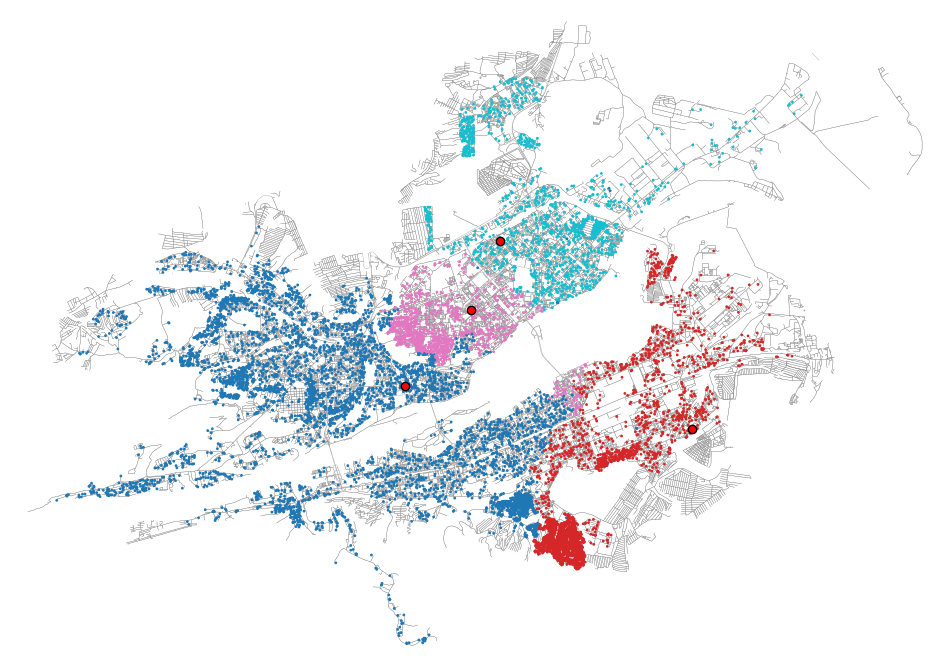

In [209]:
# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[dynamic_nodes.keys()].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    )
buildings_set_2.plot(
    ax=ax,
    column='nearest',
    markersize=1
    )


## Алгоритм LSCP жадного добавления

In [7]:
from fire_units.metrics import CoverIndexBuilding
from genesis.core import LSCPBase, MCLPBase, PointSelectorBase, StopCaseBase
from genesis.mclp import NodesMetric
from genesis.tools import list_dict_concat


class LSCP_ADD(LSCPBase):
    '''
    Решение задачи LSCP алгоритмом жадного добавления.
    '''
    def __init__(self,
                 state_function: StateBase,
                 matrix: pd.DataFrame,
                 metric_function: MetricBase,
                 ip_val: int=10,
                 delay = DELAY_TIME,
                 mclp_function: MCLPBase = None,
                 point_selector: PointSelectorBase = None,
                 stop_case_function: StopCaseBase = None,
                 names_pattern: str = '{}',
                 start_names_index: int = 1,
                 after_mclp_function: callable = None,
                 **kwargs):

        # Сохраняем матрицу прибытия в пределах максимального времени прибытия
        self.matrix = matrix
        self.ip_val = ip_val
        self.delay  = delay

        self.state_function = state_function
        self.after_mclp_function = after_mclp_function
        super().__init__(mclp_function, point_selector, stop_case_function, metric_function, names_pattern, start_names_index, **kwargs)

    def __call__(self,
                 env:nx.Graph = None,
                 dynamic_nodes: dict = {},
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 nodes_list:set=None,
                 **kwargs):
        '''
        Запуск работы алгоритма

        ## Аргументы
        `env`:nx.Graph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        `nodes_list`:set=None
            Множество узлов графа которые будут рассмотрены в качестве кандидатов.
            Если не указан, то будут рассмотрены все узлы графа.
        '''

        # 0. Проверка корректности пришедших данных
        # if not isinstance(env, nx.Graph):
        #     raise TypeError("Тип аргумента `env` должен быть Graph!")
        if not static_nodes is None:
            if not (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict)):
                raise TypeError(f'Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: dict'
                                f'Имеют: {type(dynamic_nodes)}, {type(static_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
      
        # 0.1. Если статические узлы не указаны - заменяем значение переменной с None на {}
        if static_nodes is None:
            static_nodes = {}
        # if len(static_nodes) + len(dynamic_nodes) == 0:
        #     raise ValueError('Суммарное количество элементов `static_nodes` и `dynamic_nodes` не может быть равно 0! ' + \
        #                     'В случае если в `env` отсутствуют известные размещения `points`, ' + \
        #                     'используйте методы класса `BestPointsBase`')

        # Отброс узлов прикрытых имеющимися подразделениями
        matrix_temp = self.matrix.copy()
        matrix_temp = matrix_temp <= self.ip_val - self.delay
        


        # Итерации
        best_dynamic_nodes = dynamic_nodes
        iteration = 0
        name_index = self.start_names_index
        while len(matrix_temp) > 0:
            # 1. Расчет оптимального размещения подразделений
            node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
            best_dynamic_nodes[node_id] = self.names_pattern.format(name_index)
            node_column = matrix_temp[node_id]

            # Определения количества прикрытых зданий
            # covered_buildings_count += node_column.sum()
            # print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

            # Отброс прикрытых узлов
            matrix_temp = matrix_temp[node_column == False]

            
            # 2. Расчет текущей метрики
            if static_nodes is None:
                all_nodes = best_dynamic_nodes
            else:
                all_nodes = list_dict_concat(best_dynamic_nodes, static_nodes)
            # current_metric = NodesMetric(self.state_function,
            #                              self.metric_function
            #                              )(env,
            #                                list(all_nodes.keys()),
            #                                area=area)
            times, _ = self.state_function(env = env, points = all_nodes)
            current_metric = self.metric_function(times)
            # 3. Печать отчета расчета
            if not self.after_mclp_function is None:
                self.after_mclp_function(iteration=iteration,
                            best_metric=current_metric,
                            current_metric=current_metric,
                            dynamic_nodes=best_dynamic_nodes,
                            static_nodes=static_nodes)

            # 4. Если достигнута цель расчета, выходим из цикла
            if not self.stop_case_function is None:
                if self.stop_case_function(value=current_metric,
                                iteration=iteration,
                                best_metric=current_metric,
                                current_metric=current_metric,
                                dynamic_nodes=best_dynamic_nodes,
                                static_nodes=static_nodes):
                    return best_dynamic_nodes, current_metric

            # ============================================================================================
            iteration += 1
            name_index += 1

        return best_dynamic_nodes, current_metric


#==========================================================================================
lscp = LSCP_ADD(
    state_function = CoverMatrixState(matrix),
    matrix = matrix,
    metric_function = CoverIndexBuilding(buildings_set),
    after_mclp_function = lambda iteration, dynamic_nodes, best_metric, **kwargs: print(iteration, len(dynamic_nodes), best_metric),
    # stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: len(dynamic_nodes) >= 5,
    stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: current_metric >= 98,
    names_pattern = 'псч {}'
)
best_dynamic_nodes, current_metric = lscp()
len(best_dynamic_nodes), current_metric

0 1 25.492106801793025
1 2 48.02182810368349
2 3 62.42447865913078
3 4 71.40908205028259
4 5 77.13895926719938
5 6 80.15981290196842
6 7 83.00526213213799
7 8 88.50126680958877
8 9 91.61956733580199
9 10 93.2956538686416
10 11 95.08867667121419
11 12 95.94620931592283
12 13 96.60884817774313
13 14 96.99863574351978
14 15 97.3689339310076
15 16 97.79770025336192
16 17 98.12901968427207


(17, 98.12901968427207)

In [8]:
current_nodes = list(best_dynamic_nodes.keys())
times, nearest = state_func(None, current_nodes)
nearest.unique()

array(['1536378074', '355950683', '2024310814', '1537263273', '746268669',
       '750722041', '315786162', '3809461059', '420043071', '3276174454',
       '736012826', '346095617', '357878244', '356764638', '2127094731',
       '1514360543', '346105753'], dtype=object)

C:\Users\Obsidian\AppData\Local\Temp\ipykernel_16772\4062461181.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_set_2['geometry'] = buildings_set_2.geometry.centroid


<Axes: >

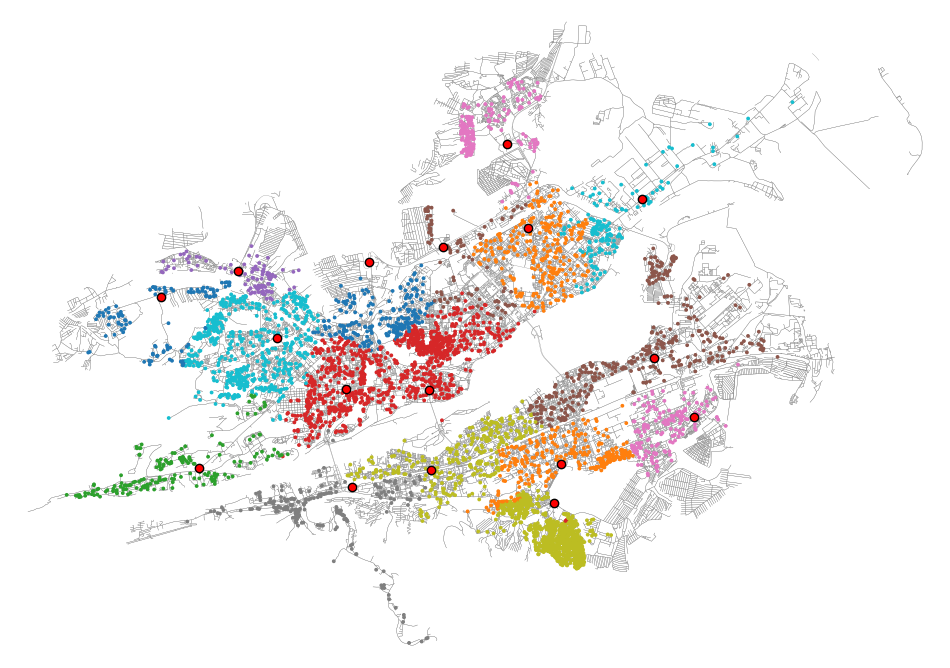

In [9]:
# current_nodes = units[:10]
current_nodes = list(best_dynamic_nodes.keys())
times, nearest = state_func(None, current_nodes)

# buildings_set.drop(['times', 'nearest'], axis=1, inplace=True)
buildings_set_2 = pd.merge(
    buildings_set,
    times,
    left_on='node',
    right_index=True
)
buildings_set_2 = pd.merge(
    buildings_set_2,
    nearest,
    left_on='node',
    right_index=True
)
buildings_set_2['geometry'] = buildings_set_2.geometry.centroid

# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[current_nodes].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    )
buildings_set_2.plot(
    ax=ax,
    column='nearest',
    markersize=3,
    )

<Axes: >

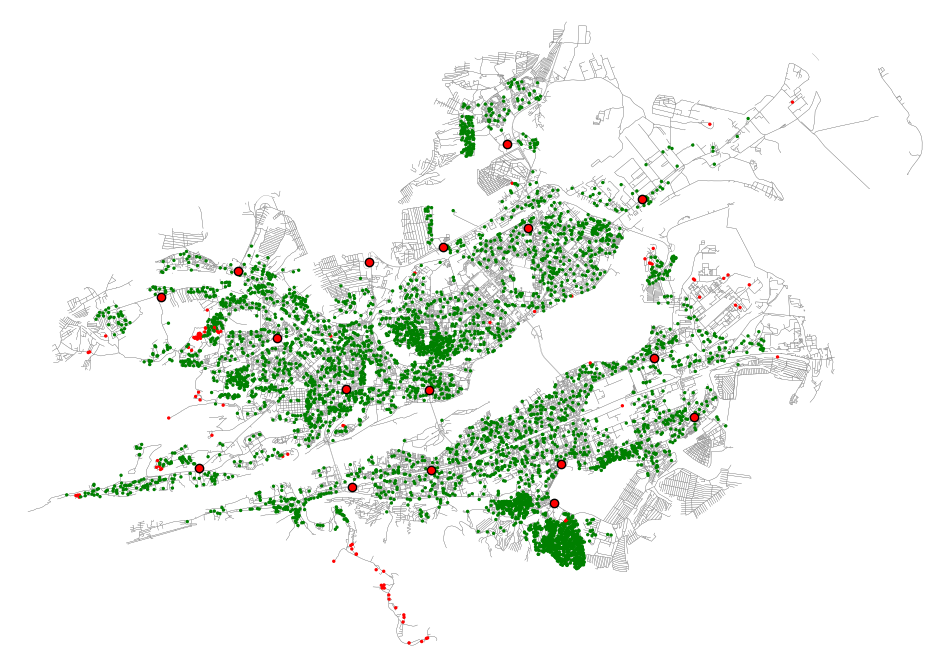

In [10]:
times10 = pd.Series({k:'g' if v<=10 else 'r' for k,v in times.items()}, name='at10')
buildings_set_3 = pd.merge(
    buildings_set_2,
    times10,
    left_on='node',
    right_index=True
)

# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[current_nodes].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    )
buildings_set_3.plot(
    ax=ax,
    color = buildings_set_3['at10'],
    markersize=2,
    )

# Тесты

In [11]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState


def iter_func(**kwds):
    'Функция вывода хода расчета'
    i = kwds['i']
    best_metric = kwds['best_metric']
    print(f'Копт: шаг {i} лучшая метирка: {best_metric}')

# mclp_history = []
def mclp_end_function(iteration, best_metric, dynamic_nodes, static_nodes, **kwargs):
    units_count = len(dynamic_nodes) + len(static_nodes)
    mclp_history.append([units_count, best_metric])
    msg = f'Итерация: {iteration} | Подразделений {units_count} | Лучшая метрика: {best_metric}    '
    print(' ')
    print(msg)

    pd.DataFrame(mclp_history, columns=['iter', 'metric']).to_csv(history_name)


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric}    ', end='\r')

def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

def print_metrics(env, dynamic_nodes, existed_units_dict, ip_val=3):
    all_nodes = {**existed_units_dict, **dynamic_nodes}
    times, _ = FirstArrivalUnitState()(env = env, points = all_nodes)
    print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(all_nodes))
    print(f'ИП-{ip_val} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times))

## ГА 1

In [23]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean, BestNodeHillClimbing_maxMean_Metric
from fire_units.metrics import ArrivalTimeBuilding
from genesis.lscp import drop_trash_points
from genesis.mclp import BestNodesGA, BestNodesKoptG
from genesis.point_selectors import RandomNodeInDistanceSelector
from genesis.stop_cases import MoreEqualStopCase, NSameStopCase
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector, FarNodeSelector, RandomNodeInDistanceSelector


time_bound = 10
target_ip  = 99.75
DISTANCE   = 500



state_func = CoverMatrixState(matrix)
metric_target = CoverIndexBuilding(buildings_set)
# metric_target = ArrivalTimeBuilding(buildings_set)
node_selector = RandomNodesSelector(nodes_list = set(matrix.columns))

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function  = state_func,
                                           metric_function = metric_target)


kopt = BestNodesKoptG(state_function          = state_func,
                       metric_function        = metric_target,
                       best_point_function    = bnhc,
                       iterations             = 5,
                       iter_calc_end_function = iter_func,
                       )


# gakopt = BestNodesGAKopt(state_function = state_func,
#                     metric_function = metric_target,
#                     kopt_function = kopt,
#                     node_selector = node_selector,                  
#                     population_size = 60,
#                     epochs = 20,
#                     elite_size = 15,
#                     epoch_end_function = epoch_end_function,
#                     mutation_max_count = 2,
#                     mutation_rate = 1,
#                     stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
#                     )

ga = BestNodesGA(state_function = state_func,
                    metric_function = metric_target,
                    node_selector = node_selector,
                    # node_selector = RandomNodeInDistanceSelector(g_nodes = ox.projection.project_gdf(nodes_gdf),
                    #                                              nodes_list = set(matrix.columns),
                    #                                              distance=DISTANCE),
                    population_size = 75,
                    epochs = 200,
                    # elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    # mutation_max_count = 0.75,
                    # mutation_rate = 1,
                    stop_case_function = NSameStopCase(50)      # Условие остановки не менее N одинаковых метрик
                    )


# lscp = LSCP_ADD(
#     state_function = CoverMatrixState(matrix),
#     matrix = matrix,
#     metric_function = CoverIndexBuilding(buildings_set),
#     after_mclp_function = lambda iteration, dynamic_nodes, best_metric, **kwargs: print(iteration, len(dynamic_nodes), best_metric),
#     # stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: len(dynamic_nodes) >= 5,
#     stop_case_function = lambda current_metric, dynamic_nodes, **kwargs: current_metric >= target_ip,
#     names_pattern = 'псч {}'
# )

# dynamic_nodes = best_dynamic_nodes
dynamic_nodes = {}
# for nodes in best_dynamic_nodes.keys():

i = 0
for n in list(best_dynamic_nodes.keys())[:5]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1
# g_nodes = list(G.nodes())
# dynamic_nodes[g_nodes[1000]] = '1'
# dynamic_nodes[g_nodes[2000]] = '2'
print(dynamic_nodes)

times, _ = CoverMatrixState(matrix)(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(best_dynamic_nodes))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))



t = TimeCheckPoint()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes2, best_metric = ga(env = G,
                                dynamic_nodes = dynamic_nodes,
                                )
# best_dynamic_nodes, best_metric = lscp(env = G,
#                                 dynamic_nodes = dynamic_nodes,
#                                 )
print('')
print('После LSCP:', len(best_dynamic_nodes2), t())

# optimal_nodes, best_metric = drop_trash_points(G,
#                                 state_func,
#                                 metric_target,
#                                 stop_case_function(target_ip = target_ip),
#                                 best_dynamic_nodes2,
#                                 # static_nodes = existed_units_dict,   
#                                 )
# print('После отброса:', len(optimal_nodes), t())

{3276174454: 'pre 0', 2024310814: 'pre 1', 750722041: 'pre 2', 1537263273: 'pre 3', 355950683: 'pre 4'}
Исходно
Новых ПСЧ: 5 Всего ПСЧ: 17
ИП-10 =  77.13895926719938 %, tпр =  8.331059839148589 8.504360982671525
До LSCP: 5
Эпоха: 137 | Лучшая метрика: 78.69810953030598    
После LSCP: 5 286.64


<Axes: >

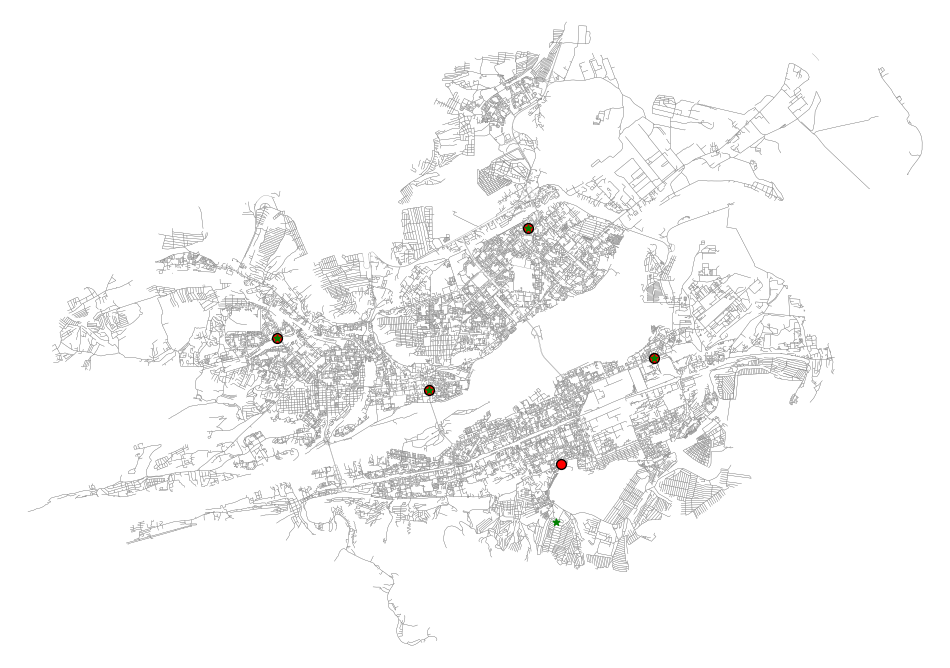

In [24]:
# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[list(best_dynamic_nodes.keys())[:len(best_dynamic_nodes2)]].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    markersize=50
    )
nodes_gdf.loc[best_dynamic_nodes2.keys()].plot(
    ax=ax,
    color='green',
    # edgecolor='black',
    zorder=1000,
    markersize=25,
    marker='*',
    )

In [13]:
times, _ = CoverMatrixState(matrix)(env = G, points = best_dynamic_nodes2)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))


ИП-10 =  47.807444942506336 %, tпр =  12.18905267626104 12.025656900740966


## Тест отброса

In [154]:
def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        # print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

In [171]:
import random
from genesis.lscp import drop_trash_points

random.shuffle(units)
best_dynamic_nodes = {}
for i, unit in enumerate(units):
    best_dynamic_nodes[unit] = f'псч {i}'
# best_dynamic_nodes


TARGET_IP = 99
cover_index = CoverIndexBuilding(buildings_set)


optimal_nodes, best_metric = drop_trash_points(G,
                                state_func,
                                cover_index,
                                stop_case_function(target_ip = TARGET_IP),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print(len(optimal_nodes), best_metric)

26 99.00604170726953


И так не работает(((